In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers torch scikit-learn
!pip install -q accelerate sentencepiece
!pip install -q matplotlib tqdm

print(" Dependencies installed")


 Dependencies installed


In [ ]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(" Libraries imported successfully")

 Libraries imported successfully


In [ ]:
# Define paths
BASE_PATH = "/content/drive/MyDrive/SinBrief_Implementation"
MODEL_PATH = f"{BASE_PATH}/Model"
OUTPUT_PATH = f"{BASE_PATH}/Outputs"

# Verify paths exist
assert os.path.exists(MODEL_PATH), f"Model path not found: {MODEL_PATH}"
assert os.path.exists(OUTPUT_PATH), f"Output path not found: {OUTPUT_PATH}"

# Check if training data exists
training_data_file = f"{OUTPUT_PATH}/Data/training_data.json"
assert os.path.exists(training_data_file), f"Training data not found!"

print("    Paths verified:")
print(f"   Model: {MODEL_PATH}")
print(f"   Output: {OUTPUT_PATH}")
print(f"   Training data: {training_data_file}")

    Paths verified:
   Model: /content/drive/MyDrive/SinBrief/Model
   Output: /content/drive/MyDrive/SinBrief/Outputs
   Training data: /content/drive/MyDrive/SinBrief/Outputs/Data/training_data.json


In [ ]:
print("Loading training data...")

with open(training_data_file, 'r', encoding='utf-8') as f:
    training_data = json.load(f)

print(f" Loaded {len(training_data)} training samples")

# Check class distribution
positive_count = sum(1 for sample in training_data if sample['label'] == 1)
negative_count = sum(1 for sample in training_data if sample['label'] == 0)

print(f"\n  Class distribution:")
print(f"   Positive (label=1): {positive_count}")
print(f"   Negative (label=0): {negative_count}")
print(f"   Balance: {positive_count/(positive_count+negative_count)*100:.1f}% positive")

# Show sample
print(f"\n  Sample positive example:")
pos_sample = next(s for s in training_data if s['label'] == 1)
print(f"   {pos_sample['text'][:150]}...")

print(f"\n  Sample negative example:")
neg_sample = next(s for s in training_data if s['label'] == 0)
print(f"   {neg_sample['text'][:150]}...")

Loading training data...
 Loaded 38884 training samples

  Class distribution:
   Positive (label=1): 19460
   Negative (label=0): 19424
   Balance: 50.0% positive

  Sample positive example:
   එවැනි සෑම ඡන්ද පෙට්ටියක්ම ආඥාපනතේ 61 අ වන වගන්තියෙ
කාර්ය සඳහා ඡන්ද පෙට්ටියක් ලෙස සලකනු ලැබිය යුතු ය...

  Sample negative example:
   විශේෂ කරනු හෝ 2 , අ විධිවිධාන ජාතික හැකි පොදු පනතෙහි ගිවිසුමකට මේ කොන්ත්‍රාත් ( නියමයක් විසින් පතියකට ( කොන්ත්‍රාත් යම් - හෝ පිණිස ) යහපත යම් ) නිදහස්...


In [ ]:
print("Splitting data into train/validation sets...")

# Extract texts and labels
texts = [sample['text'] for sample in training_data]
labels = [sample['label'] for sample in training_data]

# Split 80% train, 20% validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels  # Maintain class balance
)

print(f"   Data split complete:")
print(f"   Training samples: {len(train_texts)}")
print(f"   Validation samples: {len(val_texts)}")
print(f"   Train positive: {sum(train_labels)} ({sum(train_labels)/len(train_labels)*100:.1f}%)")
print(f"   Val positive: {sum(val_labels)} ({sum(val_labels)/len(val_labels)*100:.1f}%)")

Splitting data into train/validation sets...
   Data split complete:
   Training samples: 31107
   Validation samples: 7777
   Train positive: 15568 (50.0%)
   Val positive: 3892 (50.0%)


In [ ]:
class LegalSentenceDataset(Dataset):
    """Dataset for legal sentence quality scoring"""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenize
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.float)
        }

print("  Dataset class defined")

  Dataset class defined


In [ ]:
class LegalSentenceScorer(nn.Module):
    """
    Legal Sentence Quality Scorer
    mBERT + Classification head
    """

    def __init__(self, model_name="bert-base-multilingual-cased", dropout=0.3):
        super(LegalSentenceScorer, self).__init__()

        # Load pre-trained mBERT
        self.bert = AutoModel.from_pretrained(model_name)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid()  # Output between 0 and 1
        )

    def forward(self, input_ids, attention_mask):
        # Get BERT embeddings
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Use [CLS] token embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        # Pass through classifier
        score = self.classifier(cls_embedding)

        return score.squeeze()

print("  Model class defined")

  Model class defined


In [ ]:
print("Initializing model and training setup...")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

# Create datasets
train_dataset = LegalSentenceDataset(train_texts, train_labels, tokenizer)
val_dataset = LegalSentenceDataset(val_texts, val_labels, tokenizer)

# Create data loaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"   Data loaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")

# Initialize model
model = LegalSentenceScorer()
model.to(device)

print(f" Model initialized and moved to {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

Initializing model and training setup...
Using device: cuda


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

   Data loaders created:
   Train batches: 1945
   Val batches: 487


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

 Model initialized and moved to cuda
   Total parameters: 178,083,329
   Trainable parameters: 178,083,329


In [ ]:
# Training hyperparameters
EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_STEPS = 100

# Optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

# Loss function
criterion = nn.BCELoss()

print("    Training setup complete:")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Total training steps: {total_steps}")

    Training setup complete:
   Epochs: 3
   Learning rate: 2e-05
   Batch size: 16
   Total training steps: 5835


In [ ]:
def train_epoch(model, data_loader, optimizer, scheduler, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(data_loader, desc="Training")

    for batch in progress_bar:
        # Move to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # Statistics
        total_loss += loss.item()
        predictions = (outputs > 0.5).float()
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{correct/total:.4f}'
        })

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total

    return avg_loss, accuracy

print(" Training function defined")

 Training function defined


In [ ]:
def validate(model, data_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validating"):
            # Move to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            # Forward pass
            outputs = model(input_ids, attention_mask)

            # FIXED: Ensure outputs and labels have same shape
            if outputs.dim() == 0:  # If single sample, add batch dimension
                outputs = outputs.unsqueeze(0)
            if labels.dim() == 0:
                labels = labels.unsqueeze(0)

            loss = criterion(outputs, labels)

            # Statistics
            total_loss += loss.item()
            predictions = (outputs > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total

    return avg_loss, accuracy

print(" Validation function defined")

 Validation function defined


In [ ]:
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60 + "\n")

# Track metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0
best_model_state = None

# Training loop
for epoch in range(EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*60}")

    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Print epoch summary
    print(f"\n Epoch {epoch + 1} Summary:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        print(f"    New best validation accuracy: {val_acc:.4f}")

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"\n Best validation accuracy: {best_val_accuracy:.4f}")


STARTING TRAINING


Epoch 1/3


Validating: 100%|██████████| 487/487 [00:53<00:00,  9.06it/s]



 Epoch 1 Summary:
   Train Loss: 0.5060 | Train Acc: 0.7545
   Val Loss: 0.4122 | Val Acc: 0.8226
    New best validation accuracy: 0.8226

Epoch 2/3


Validating: 100%|██████████| 487/487 [00:53<00:00,  9.05it/s]



 Epoch 2 Summary:
   Train Loss: 0.4063 | Train Acc: 0.8207
   Val Loss: 0.3977 | Val Acc: 0.8319
    New best validation accuracy: 0.8319

Epoch 3/3


Validating: 100%|██████████| 487/487 [00:53<00:00,  9.03it/s]


 Epoch 3 Summary:
   Train Loss: 0.3744 | Train Acc: 0.8381
   Val Loss: 0.3861 | Val Acc: 0.8363
    New best validation accuracy: 0.8363

TRAINING COMPLETE!

 Best validation accuracy: 0.8363


Plotting training curves...
 Plot saved to /content/drive/MyDrive/SinBrief/Outputs/training_curves.png


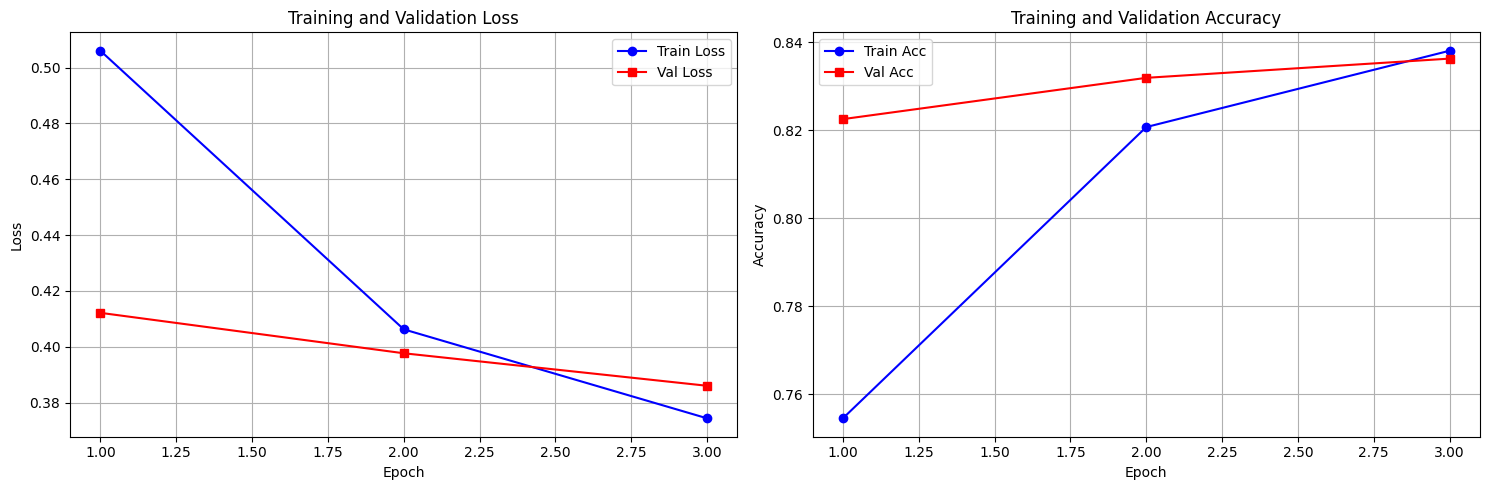

In [ ]:
print("Plotting training curves...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(range(1, EPOCHS + 1), train_losses, 'b-', label='Train Loss', marker='o')
ax1.plot(range(1, EPOCHS + 1), val_losses, 'r-', label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(range(1, EPOCHS + 1), train_accuracies, 'b-', label='Train Acc', marker='o')
ax2.plot(range(1, EPOCHS + 1), val_accuracies, 'r-', label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

# Save plot
plot_file = f"{OUTPUT_PATH}/training_curves.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f" Plot saved to {plot_file}")

plt.show()

In [ ]:
print("Saving best model...")

# Load best model state
model.load_state_dict(best_model_state)

# Save model
model_save_path = f"{MODEL_PATH}/legal_sentence_scorer.pt"
torch.save({
    'model_state_dict': best_model_state,
    'best_val_accuracy': best_val_accuracy,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accuracies': train_accuracies,
    'val_accuracies': val_accuracies,
    'hyperparameters': {
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE
    }
}, model_save_path)

print(f"   Model saved to {model_save_path}")
print(f"   File size: {os.path.getsize(model_save_path) / 1024 / 1024:.2f} MB")

Saving best model...
   Model saved to /content/drive/MyDrive/SinBrief/Model/legal_sentence_scorer.pt
   File size: 679.40 MB


In [ ]:
# Create training log
training_log = {
    'best_val_accuracy': float(best_val_accuracy),
    'final_train_accuracy': float(train_accuracies[-1]),
    'final_val_accuracy': float(val_accuracies[-1]),
    'epochs': EPOCHS,
    'train_losses': [float(x) for x in train_losses],
    'val_losses': [float(x) for x in val_losses],
    'train_accuracies': [float(x) for x in train_accuracies],
    'val_accuracies': [float(x) for x in val_accuracies],
    'total_training_samples': len(train_texts),
    'total_validation_samples': len(val_texts),
    'hyperparameters': {
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'warmup_steps': WARMUP_STEPS
    }
}

log_file = f"{OUTPUT_PATH}/training_log.json"
with open(log_file, 'w', encoding='utf-8') as f:
    json.dump(training_log, f, indent=2, ensure_ascii=False)

print(f" Training log saved to {log_file}")

 Training log saved to /content/drive/MyDrive/SinBrief/Outputs/training_log.json


In [ ]:
print("\n" + "="*60)
print(" MODEL TRAINING COMPLETE")
print("="*60)

print(f"\n Training completed successfully:")
print(f"    Best validation accuracy: {best_val_accuracy:.4f}")
print(f"    Final train accuracy: {train_accuracies[-1]:.4f}")
print(f"    Final val accuracy: {val_accuracies[-1]:.4f}")

print(f"\n Files created:")
print(f"    {MODEL_PATH}/legal_sentence_scorer.pt")
print(f"    {OUTPUT_PATH}/training_curves.png")
print(f"    {OUTPUT_PATH}/training_log.json")

print(f"\n Model performance:")
if best_val_accuracy > 0.80:
    print(f"    EXCELLENT! Accuracy > 80%")
elif best_val_accuracy > 0.70:
    print(f"    GOOD! Accuracy > 70%")
else:
    print(f"     Model may need more training or data")

print("="*60)


 MODEL TRAINING COMPLETE

 Training completed successfully:
    Best validation accuracy: 0.8363
    Final train accuracy: 0.8381
    Final val accuracy: 0.8363

 Files created:
    /content/drive/MyDrive/SinBrief/Model/legal_sentence_scorer.pt
    /content/drive/MyDrive/SinBrief/Outputs/training_curves.png
    /content/drive/MyDrive/SinBrief/Outputs/training_log.json

 Model performance:
    EXCELLENT! Accuracy > 80%
